In [259]:
import pandas as pd
import numpy as np
from datetime import datetime
import yfinance as yf
from meteostat import Point, Daily
import os
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("LSTM FEATURE ENGINEERING PIPELINE")
print("="*50)

LSTM FEATURE ENGINEERING PIPELINE


In [260]:
print("\nLoading primary price data...")

# Load the Henry Hub spot price data
df = pd.read_csv('train_henry_hub_natural_gas_spot_price_daily 1.csv', 
                 index_col='date', 
                 parse_dates=True)

# Drop unnecessary column
df.drop(columns=['source'], inplace=True, errors='ignore')

# Calculate price variation (target variable)
df['price_variation'] = df['price_usd_per_mmbtu'].diff()
df['price_variation'].fillna(0, inplace=True)  # Handle NaN from first row

print(f"Initial price data shape: {df.shape}")
print("Price data sample:")
print(df.head(3))


Loading primary price data...
Initial price data shape: (5996, 2)
Price data sample:
            price_usd_per_mmbtu  price_variation
date                                            
1997-01-07                 3.82             0.00
1997-01-08                 3.80            -0.02
1997-01-09                 3.61            -0.19


In [261]:
print("\nCreating core features (without manual lag columns)...")

# For LSTM, we keep the raw time series and will create sequences later
# Instead of creating price_lag_1, price_lag_2, etc., we keep:
# - The current price (will be shifted appropriately for sequences)
# - Time-based features (seasonality)
# - External features (weather, futures, sentiment)

# Add time-based features (seasonality)
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek  # Monday=0, Sunday=6
df['week_of_year'] = df.index.isocalendar().week.astype(int)

df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

print("Time-based features added: month, day_of_week, week_of_year")


Creating core features (without manual lag columns)...
Time-based features added: month, day_of_week, week_of_year


In [262]:
print("\nFetching weather features...")

# Check if precomputed weather features exist
weather_file = "weather_features.csv"
if os.path.exists(weather_file):
    print(f"  Loading precomputed weather features from {weather_file}")
    weather_features = pd.read_csv(weather_file, index_col=0, parse_dates=True)
else:
    print("  Computing weather features from scratch...")
    
    # Define time period
    start_date = datetime(1997, 1, 7)
    end_date = datetime(2025, 9, 22)
    
    # Define weather stations (Chicago, New York, Dallas)
    stations_info = {
        'chicago': Point(41.9742, -87.9073),  # KORD
        'newyork': Point(40.6413, -73.7781),  # KJFK
        'dallas':  Point(32.8998, -97.0403)   # KDFW
    }
    
    # Base temperature for HDD/CDD calculation (18°C is standard)
    BASE_TEMP_C = 18.0
    
    # Fetch and process weather data for each station
    all_weather_data = {}
    for name, location in stations_info.items():
        print(f"  -> Fetching data for {name}...")
        data = Daily(location, start_date, end_date)
        data = data.fetch()
        
        # Calculate HDD and CDD
        data['HDD'] = (BASE_TEMP_C - data['tavg']).clip(lower=0)
        data['CDD'] = (data['tavg'] - BASE_TEMP_C).clip(lower=0)
        
        all_weather_data[name] = data[['HDD', 'CDD']]
    
    # Aggregate across stations (simple average)
    hdd_df = pd.DataFrame({name: df['HDD'] for name, df in all_weather_data.items()})
    cdd_df = pd.DataFrame({name: df['CDD'] for name, df in all_weather_data.items()})
    
    weather_features = pd.DataFrame(index=hdd_df.index)
    weather_features['HDD_avg'] = hdd_df.mean(axis=1)
    weather_features['CDD_avg'] = cdd_df.mean(axis=1)
    weather_features.index.name = 'date'
    
    # CRITICAL: SHIFT WEATHER FEATURES BY 1 DAY TO PREVENT LEAKAGE
    print("Shifting weather features by 1 day to prevent data leakage...")
    weather_features = weather_features.shift(1)
    
    # Save for future use
    weather_features.to_csv(weather_file)
    print(f"  Weather features computed and saved to {weather_file}")

print("Weather features sample:")
print(weather_features.head(3))


Fetching weather features...
  Loading precomputed weather features from weather_features.csv
Weather features sample:
              HDD_avg  CDD_avg
date                          
1997-01-07        NaN      NaN
1997-01-08  20.300000      0.0
1997-01-09  20.333333      0.0


In [263]:
print("\nLoading GDELT sentiment features...")

# Load GDELT data
gdelt_file = 'gdelt_bigquery.csv'
if os.path.exists(gdelt_file):
    df_gdelt = pd.read_csv(gdelt_file, index_col='EventDate', parse_dates=True)
    df_gdelt.drop(columns=['HasNews'], inplace=True, errors='ignore')
    
    # IMPORTANT: Shift by 1 to prevent data leakage (can't use today's news to predict today's price)
    df_gdelt = df_gdelt.shift(1)
    
    print("GDELT sentiment features loaded and shifted to prevent leakage")
    print("GDELT features sample:")
    print(df_gdelt.head(3))
else:
    print(f"WARNING: GDELT file {gdelt_file} not found. Continuing without sentiment features.")
    df_gdelt = None


Loading GDELT sentiment features...
GDELT sentiment features loaded and shifted to prevent leakage
GDELT features sample:
            DecayedEmotionalScore
EventDate                        
1997-01-07                    NaN
1997-01-08                    0.0
1997-01-09                    0.0


In [264]:
print("\nLoading Gas Storage features...")
# Load Gas Storage data
gas_storage_file = 'codeml_gas_storage.csv'
if os.path.exists(gas_storage_file):
    df_gas_storage = pd.read_csv(gas_storage_file, index_col='date', parse_dates=True)
    df_gas_storage = df_gas_storage.rename(columns={'Total Lower 48 value': 'gas_storage_level'})
    
    # Shift by 1 to prevent leakage
    df_gas_storage = df_gas_storage.shift(1)
    
    print("Gas Storage features loaded and shifted to prevent leakage")
    print("Gas Storage features sample:")
    print(df_gas_storage.head(3))


Loading Gas Storage features...
Gas Storage features loaded and shifted to prevent leakage
Gas Storage features sample:
            gas_storage_level
date                         
1993-12-31                NaN
1994-01-07             2322.0
1994-01-14             2186.0


In [265]:
def get_closing_price(company_name, start_date, end_date):
    """
    Get the closing price of a company's stock on a specific date range.

    Parameters:
    company_name (str): Stock ticker symbol (e.g., 'AAPL', 'GOOGL', 'MSFT')
    start_date (str): Start date in 'YYYY-MM-DD' format
    end_date (str): End date in 'YYYY-MM-DD' format

    Returns:
    Series: Closing prices for each day in the date range, or None if not available
    """
    try:
        start_date = datetime.strptime(start_date, '%Y-%m-%d')
        end_date = datetime.strptime(end_date, '%Y-%m-%d')

        stock = yf.Ticker(company_name)
        data = stock.history(start=start_date, end=end_date)

        if not data.empty:
            # print(f"Data: {data}")
            return data['Close']
        else:
            print("No Data Available")
            # Try to get the closest trading day if exact date has no data
            # Note: This part might not be necessary if the user always provides a range
            # but keeping it for robustness.
            data = stock.history(start=start_date, period="5d") # Using start_date here
            if not data.empty:
                return data['Close'] # Returning the series for the 5-day period
            else:
                return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

 # Yahoo Finance pour prix du gaz
  # Get dates from 1997-01-07 to 2019-12-31
henry_hub_price = get_closing_price('NG=F', "2000-01-01", "2025-09-22")

# Merge the daily date index with the Yahoo Finance data
# This aligns the data and keeps all dates from the daily index
if henry_hub_price is not None:
    # On normalise la date aussi
    henry_hub_price.index = pd.to_datetime(henry_hub_price.index.date)
    henry_hub_price = henry_hub_price.shift(1)
    print("Henry Hub futures prices loaded and shifted to prevent leakage")
    print(henry_hub_price.head(3))

Henry Hub futures prices loaded and shifted to prevent leakage
2000-08-30      NaN
2000-08-31    4.805
2000-09-01    4.780
Name: Close, dtype: float64


In [266]:
print("\nMerging all features into a single dataframe...")

# Start with our primary price data
feature_df = df.copy()

# Add weather features (align by date)
feature_df = pd.merge(feature_df, weather_features, left_index=True, right_index=True, how='left')

# Add GDELT sentiment (if available)
if df_gdelt is not None and not df_gdelt.empty:
    feature_df = pd.merge(feature_df, df_gdelt, left_index=True, right_index=True, how='left')

# Add Gas Storage features (if available)
if df_gas_storage is not None and not df_gas_storage.empty:
    feature_df = pd.merge(feature_df, df_gas_storage, left_index=True, right_index=True, how='left')

# # Add Henry Hub futures prices (if available)
# if henry_hub_price is not None:
#     feature_df["Close"] = henry_hub_price

# Fill any remaining NaN values (only forward-fill to prevent leakage)
feature_df = feature_df.fillna(method='ffill')
feature_df = feature_df.fillna(method='bfill')  # Only if necessary at the very beginning

# Trim to reasonable date range (avoid early periods with missing features)
feature_df = feature_df.loc['2000-01-01':]

print(f"Final feature dataframe shape: {feature_df.shape}")
print("Feature dataframe sample:")
print(feature_df.head(3))


Merging all features into a single dataframe...
Final feature dataframe shape: (5217, 11)
Feature dataframe sample:
            price_usd_per_mmbtu  price_variation  month  day_of_week  \
date                                                                   
2000-01-03                 2.30             0.00      1            0   
2000-01-04                 2.16             0.00      1            1   
2000-01-05                 2.17             0.01      1            2   

            week_of_year  month_sin  month_cos    HDD_avg  CDD_avg  \
date                                                                 
2000-01-03             1        0.5   0.866025   6.433333      0.4   
2000-01-04             1        0.5   0.866025   8.566667      0.0   
2000-01-05             1        0.5   0.866025  13.633333      0.0   

            DecayedEmotionalScore  gas_storage_level  
date                                                  
2000-01-03                    0.0             2663.0  
2000-0

In [267]:
print("\nPreparing data for LSTM (sequence creation)...")

def create_sequences(data, target_col, seq_length=30):
    """
    Create sequences for LSTM from time series data.
    
    Parameters:
    data (DataFrame): The time series data
    target_col (str): Name of the target column
    seq_length (int): Length of each sequence (number of time steps)
    
    Returns:
    X (numpy array): Input sequences [samples, seq_length, features]
    y (numpy array): Target values [samples]
    dates (list): Dates corresponding to each target value
    """
    print(f"  Creating sequences of length {seq_length}...")
    
    # Identify features (all columns except target)
    feature_cols = [col for col in data.columns if col != target_col and col != "price_usd_per_mmbtu"]
    print(f"  Using {len(feature_cols)} features: {feature_cols}")
    
    X = []
    y = []
    dates = []
    
    # Create sequences
    for i in range(len(data) - seq_length):
        # Get sequence of features
        seq = data[feature_cols].iloc[i:i+seq_length].values
        # Get target value (next day's price variation)
        target = data[target_col].iloc[i+seq_length]
        # Get date of target
        date = data.index[i+seq_length]
        
        X.append(seq)
        y.append(target)
        dates.append(date)
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"  Created {len(X)} sequences with shape: {X.shape}")
    print(f"  Target shape: {y.shape}")
    
    return X, y, dates

# Define sequence parameters
SEQUENCE_LENGTH = 30  # Using 30 days of history
TARGET_COLUMN = 'price_variation'

# Create sequences
X, y, sequence_dates = create_sequences(feature_df, TARGET_COLUMN, SEQUENCE_LENGTH)

print("\nLSTM feature engineering complete!")
print(f"Final sequence data shapes:")
print(f"  X (sequences): {X.shape}  [samples, time_steps, features]")
print(f"  y (targets): {y.shape}")


Preparing data for LSTM (sequence creation)...
  Creating sequences of length 30...
  Using 9 features: ['month', 'day_of_week', 'week_of_year', 'month_sin', 'month_cos', 'HDD_avg', 'CDD_avg', 'DecayedEmotionalScore', 'gas_storage_level']
  Created 5187 sequences with shape: (5187, 30, 9)
  Target shape: (5187,)

LSTM feature engineering complete!
Final sequence data shapes:
  X (sequences): (5187, 30, 9)  [samples, time_steps, features]
  y (targets): (5187,)


In [268]:
# Création d'un dataframe price_lag pour pouvoir additionner les prix aux taux de variation afin d'obtenir le vrai score
df_price_lag = pd.read_csv(
    'donnees_recentes.csv',
    index_col='Date',
    parse_dates=True
)
df_price_lag = df_price_lag.shift(1)
df_price_lag["testing"] = df_price_lag["2020-01-02":"2025-09-22"]


In [269]:
# Assuming you've already created your sequences with the feature engineering code
print(f"Sequence data shapes:")
print(f"X shape: {X.shape}  # [samples, time_steps, features]")
print(f"y shape: {y.shape}  # [samples]")

# Split into training and validation sets (chronological split)
split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"\nTraining set: {X_train.shape[0]} sequences")
print(f"Validation set: {X_val.shape[0]} sequences")

Sequence data shapes:
X shape: (5187, 30, 9)  # [samples, time_steps, features]
y shape: (5187,)  # [samples]

Training set: 4668 sequences
Validation set: 519 sequences



Building LSTM model with PyTorch...
Using device: cuda
GPU: NVIDIA GeForce RTX 3060

Starting model training...


Epoch 1/100 | Train Loss: 0.104260 | Val Loss: 0.026662 | LR: 0.00100000


Epoch 2/100 | Train Loss: 0.085626 | Val Loss: 0.026110 | LR: 0.00100000


Epoch 3/100 | Train Loss: 0.082488 | Val Loss: 0.025866 | LR: 0.00100000


Epoch 4/100 | Train Loss: 0.082020 | Val Loss: 0.025774 | LR: 0.00100000


...

Epoch 31/100 | Train Loss: 0.081430 | Val Loss: 0.025590 | LR: 0.00050000


Epoch 32/100 | Train Loss: 0.081433 | Val Loss: 0.025606 | LR: 0.00025000


Epoch 33/100 | Train Loss: 0.081458 | Val Loss: 0.025599 | LR: 0.00025000


Epoch 34/100 | Train Loss: 0.081472 | Val Loss: 0.025600 | LR: 0.00025000


Epoch 35/100 | Train Loss: 0.081443 | Val Loss: 0.025610 | LR: 0.00025000

Early stopping triggered after 35 epochs

--- Evaluation Results ---
Training RMSE: 0.285418
Training Score: 0.777957
Validation RMSE: 0.159666
Validation Score: 0.862317


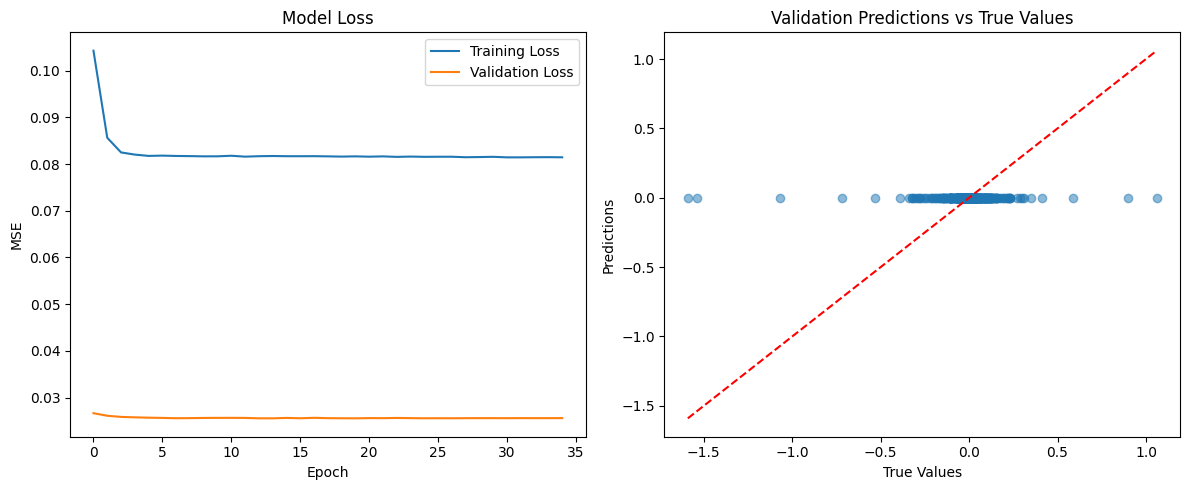


Model saved successfully!


In [270]:
# ======================================
# LSTM MODEL TRAINING WITH PYTORCH
# ======================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm

print("\nBuilding LSTM model with PyTorch...")

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Create a custom dataset for time series
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create dataset and dataloaders
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)

BATCH_SIZE = 16  # Start small to avoid memory issues
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)  # IMPORTANT: No shuffle for time series
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size * 2, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        
    def forward(self, x):
        # x shape: [batch_size, sequence_length, features]
        lstm_out, _ = self.lstm(x)
        
        # Take only the output from the final time step
        lstm_out = lstm_out[:, -1, :]
        
        # Apply batch norm, dropout and fully connected layers
        x = self.batch_norm(lstm_out)
        x = self.dropout(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Initialize model
input_size = X_train.shape[2]  # Number of features
model = LSTMModel(input_size=input_size)
model.to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Training function
def train_model(model, train_loader, val_loader, epochs=100, patience=15):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model = None
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', leave=False):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch).squeeze()
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch).squeeze()
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.8f}')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
    
    # Load best model
    if best_model is not None:
        model.load_state_dict(best_model)
    
    return model, train_losses, val_losses

# Train the model
print("\nStarting model training...")
model, train_losses, val_losses = train_model(
    model, 
    train_loader, 
    val_loader,
    epochs=100,
    patience=15
)

# Evaluate the model
def evaluate_model(model, X, y):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        predictions = model(X_tensor).cpu().numpy().flatten()
    
    rmse = np.sqrt(mean_squared_error(y, predictions))
    score = 1 / (1 + rmse)
    
    return predictions, rmse, score

# Evaluate on training and validation sets
train_pred, train_rmse, train_score = evaluate_model(model, X_train, y_train)
val_pred, val_rmse, val_score = evaluate_model(model, X_val, y_val)

print("\n--- Evaluation Results ---")
print(f"Training RMSE: {train_rmse:.6f}")
print(f"Training Score: {train_score:.6f}")
print(f"Validation RMSE: {val_rmse:.6f}")
print(f"Validation Score: {val_score:.6f}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_val, val_pred, alpha=0.5)
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Validation Predictions vs True Values')

plt.tight_layout()
plt.savefig('pytorch_lstm_evaluation.png')
plt.show()

# Save the model
torch.save(model.state_dict(), 'natural_gas_lstm_model.pth')
print("\nModel saved successfully!")

In [271]:
# ======================================#
# PREDICTION FOR SUBMISSION PERIOD (2020-01-02 to 2025-09-22)
# ======================================

print("\n[STEP 13] Generating predictions for submission period...")

# 1. Load the recent data for prediction
print("Loading recent data for prediction...")
df_predict = pd.read_csv('donnees_recentes.csv', 
                         index_col='Date', 
                         parse_dates=True)

df_predict = df_predict["2015-01-01":] 

df_predict['price_variation'] = df_predict['price_usd_per_mmbtu'].diff()
df_predict['price_variation'].fillna(0, inplace=True)

print(f"Recent data shape: {df_predict.shape}")
print("Recent data sample:")
print(df_predict.head(3))

# 2. Create features for prediction data
print("\n[STEP 14] Creating features for prediction data...")

feature_df_predict = df_predict.copy()

# Add time-based features
feature_df_predict['month'] = feature_df_predict.index.month
feature_df_predict['day_of_week'] = feature_df_predict.index.dayofweek
feature_df_predict['week_of_year'] = feature_df_predict.index.isocalendar().week.astype(int)

feature_df_predict['month_sin'] = np.sin(2 * np.pi * feature_df_predict['month']/12)
feature_df_predict['month_cos'] = np.cos(2 * np.pi * feature_df_predict['month']/12)

# Merge with weather, GDELT, and Gas Storage features (all already shifted)
feature_df_predict = pd.merge(feature_df_predict, weather_features, left_index=True, right_index=True, how='left')
if df_gdelt is not None and not df_gdelt.empty:
    feature_df_predict = pd.merge(feature_df_predict, df_gdelt, left_index=True, right_index=True, how='left')
if df_gas_storage is not None and not df_gas_storage.empty:
    feature_df_predict = pd.merge(feature_df_predict, df_gas_storage, left_index=True, right_index=True, how='left')

# Fill any remaining NaN values
feature_df_predict = feature_df_predict.fillna(method='ffill')
feature_df_predict = feature_df_predict.fillna(method='bfill')

# --- THE FIX: START GATHERING HISTORY EARLIER ---
# By starting in November, we guarantee we have enough data for the first sequence in January.
feature_df_predict = feature_df_predict["2019-11-01":] 
# --- END FIX ---

print(f"Prediction feature dataframe shape: {feature_df_predict.shape}")
print("Prediction feature sample:")
print(feature_df_predict.head(3))


print("\n[DEBUG] Verifying feature alignment for LSTM model...")

LSTM_FEATURES = [
    'month', 'day_of_week', 'week_of_year', 'HDD_avg', 'CDD_avg', 
    'DecayedEmotionalScore', 'gas_storage_level', 'month_sin', 'month_cos',
]

feature_df_predict_aligned = feature_df_predict[LSTM_FEATURES]
feature_df_price = feature_df_predict["price_usd_per_mmbtu"]

print("Features used for prediction:", feature_df_predict_aligned.columns.tolist())


print("\n[STEP 15] Creating prediction sequences...")
SEQUENCE_LENGTH = 30

X_predict_sequences = []
dates_for_predictions = []
feature_values = feature_df_predict_aligned.values

for i in range(SEQUENCE_LENGTH, len(feature_values)):
    seq = feature_values[i-SEQUENCE_LENGTH:i]
    X_predict_sequences.append(seq)
    dates_for_predictions.append(feature_df_predict_aligned.index[i])

X_submission = np.array(X_predict_sequences)
print(f"Created {X_submission.shape[0]} sequences for submission with shape: {X_submission.shape}")

if X_submission.shape[2] != len(LSTM_FEATURES):
    raise ValueError("Feature count mismatch!")
else:
    print("\nSUCCESS: Input shape matches model requirements!")


[STEP 13] Generating predictions for submission period...
Loading recent data for prediction...
Recent data shape: (2719, 2)
Recent data sample:
            price_usd_per_mmbtu  price_variation
Date                                            
2015-01-02                 3.01             0.00
2015-01-05                 3.22             0.21
2015-01-06                 2.98            -0.24

[STEP 14] Creating features for prediction data...
Prediction feature dataframe shape: (1484, 11)
Prediction feature sample:
            price_usd_per_mmbtu  price_variation  month  day_of_week  \
Date                                                                   
2019-11-01                 2.54            -0.19     11            4   
2019-11-04                 2.77             0.23     11            0   
2019-11-05                 2.77             0.00     11            1   

            week_of_year  month_sin  month_cos    HDD_avg  CDD_avg  \
Date                                                

In [272]:
# ======================================#
# PREDICTION AND SUBMISSION FILE GENERATION (USING N-1 ACTUAL DATA)
# ======================================

# 4. Generate predictions for the variation
print("\n[STEP 16] Generating predictions...")
model.eval()
batch_size = 16
all_predictions = []
for i in range(0, len(X_submission), batch_size):
    batch = X_submission[i:i+batch_size]
    batch_tensor = torch.tensor(batch, dtype=torch.float32).to(device)
    with torch.no_grad():
        predictions_batch = model(batch_tensor)
        all_predictions.append(predictions_batch.cpu().numpy())
    if i % (batch_size * 10) == 0:
        print(f"  Processed {i}/{len(X_submission)} sequences...")

predicted_variations = np.concatenate(all_predictions).flatten()
print(f"Generated {len(predicted_variations)} predictions")


# 5. Create submission dataframe using the n-1 approach
print("\n[STEP 17] Creating submission file...")

# 1. Load the submission template
submission_df = pd.read_csv('test-template.csv', index_col='id', parse_dates=True)

# 2. Create a DataFrame with all generated predictions and their corresponding dates
all_predictions_df = pd.DataFrame({
    'predicted_variation': predicted_variations
}, index=dates_for_predictions)

# --- NEW N-1 LOGIC ---

# 3. Load the full historical price data to get the lagged price for each day
price_df = pd.read_csv('donnees_recentes.csv', index_col='Date', parse_dates=True)

# 4. Create a 'price_lag' column. The value for any date 'd' will be the price from 'd-1'.
# This gives us the actual n-1 price for every prediction.
price_df['price_lag'] = price_df['price_usd_per_mmbtu'].shift(1)

# 5. Merge this lagged price into our predictions DataFrame.
# We use a left merge to ensure we only consider the dates we made predictions for.
all_predictions_df = all_predictions_df.merge(
    price_df[['price_lag']],
    left_index=True,
    right_index=True,
    how='left'
)

# 6. The final predicted price is simply the actual lagged price + the predicted variation.
# This completely avoids compounding error.
all_predictions_df['predicted_price'] = all_predictions_df['price_lag'] + all_predictions_df['predicted_variation']

# --- END NEW LOGIC ---

# 7. Update the submission DataFrame with the correctly calculated prices
submission_df['price_usd_per_mmbtu'] = np.nan
predictions_to_merge = all_predictions_df.rename(columns={'predicted_price': 'price_usd_per_mmbtu'})
submission_df.update(predictions_to_merge)


# Save to CSV
submission_df.to_csv('submission.csv')

print("\nSubmission file created successfully!")
print(f"Submission range: {submission_df.index.min()} to {submission_df.index.max()}")
print(f"Number of predictions: {len(submission_df)}")
print("\nFirst 5 predictions:")
print(submission_df.head())

# Verification Step
print("\n[VERIFICATION] Checking for issues...")
if submission_df['price_usd_per_mmbtu'].isnull().any():
    missing_count = submission_df['price_usd_per_mmbtu'].isnull().sum()
    print(f"WARNING: {missing_count} predictions are missing (NaN).")
else:
    print("SUCCESS: All required dates were found and predicted.")


[STEP 16] Generating predictions...
  Processed 0/1454 sequences...
  Processed 160/1454 sequences...
  Processed 320/1454 sequences...
  Processed 480/1454 sequences...
  Processed 640/1454 sequences...
  Processed 800/1454 sequences...
  Processed 960/1454 sequences...
  Processed 1120/1454 sequences...
  Processed 1280/1454 sequences...
  Processed 1440/1454 sequences...
Generated 1454 predictions

[STEP 17] Creating submission file...

Submission file created successfully!
Submission range: 2020-01-02 00:00:00 to 2025-09-22 00:00:00
Number of predictions: 1434

First 5 predictions:
            price_usd_per_mmbtu
id                             
2020-01-02             2.082831
2020-01-03             2.042747
2020-01-06             2.052734
2020-01-07             2.092713
2020-01-08             2.162733

[VERIFICATION] Checking for issues...
SUCCESS: All required dates were found and predicted.
